In [14]:

!pip install pandas scikit-learn matplotlib seaborn xgboost transformers mlxtend


In [15]:

import pandas as pd

rfm = pd.DataFrame({
    'user.uid': [1, 2, 3, 4],
    'Recency': [10, 5, 3, 8],
    'Frequency': [5, 10, 3, 7],
    'Monetary': [100, 200, 50, 120]
})

rfm['RFM_segment'] = ['High Value', 'Low Value', 'Low Value', 'Medium Value']


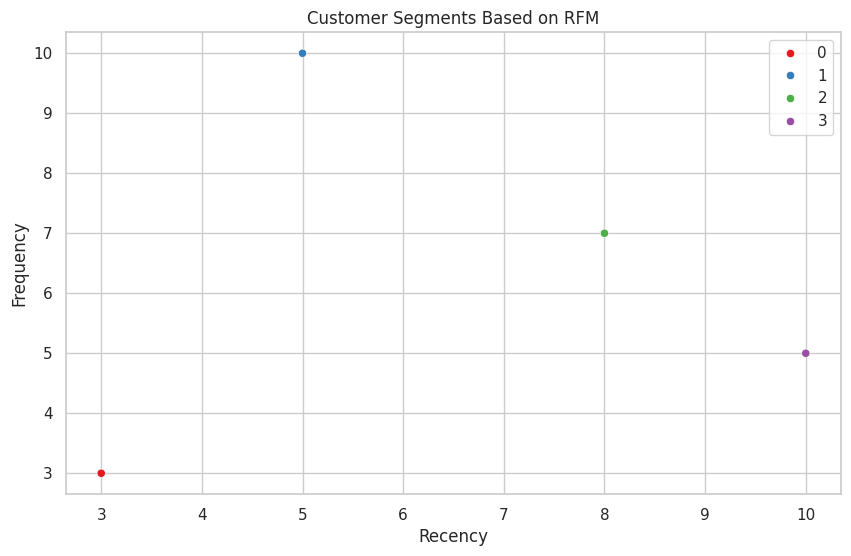

In [16]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sns
X = rfm[['Recency', 'Frequency', 'Monetary']]
kmeans = KMeans(n_clusters=4, random_state=0)
rfm['Cluster'] = kmeans.fit_predict(X)

plt.figure(figsize=(10, 6))
sns.scatterplot(data=rfm, x='Recency', y='Frequency', hue='Cluster', palette='Set1')
plt.title('Customer Segments Based on RFM')
plt.xlabel('Recency')
plt.ylabel('Frequency')
plt.legend()
plt.show()


In [17]:

rfm = rfm.rename(columns={'Cluster': 'CustomerSegment'})


display(rfm.head())

,user.uid,Recency,Frequency,Monetary,RFM_segment,CustomerSegment
0,1,10,5,100,High Value,3
1,2,5,10,200,Low Value,1
2,3,3,3,50,Low Value,0
3,4,8,7,120,Medium Value,2


The 'Cluster' column has been successfully renamed to 'CustomerSegment' in the `rfm` DataFrame, as shown in the output above.

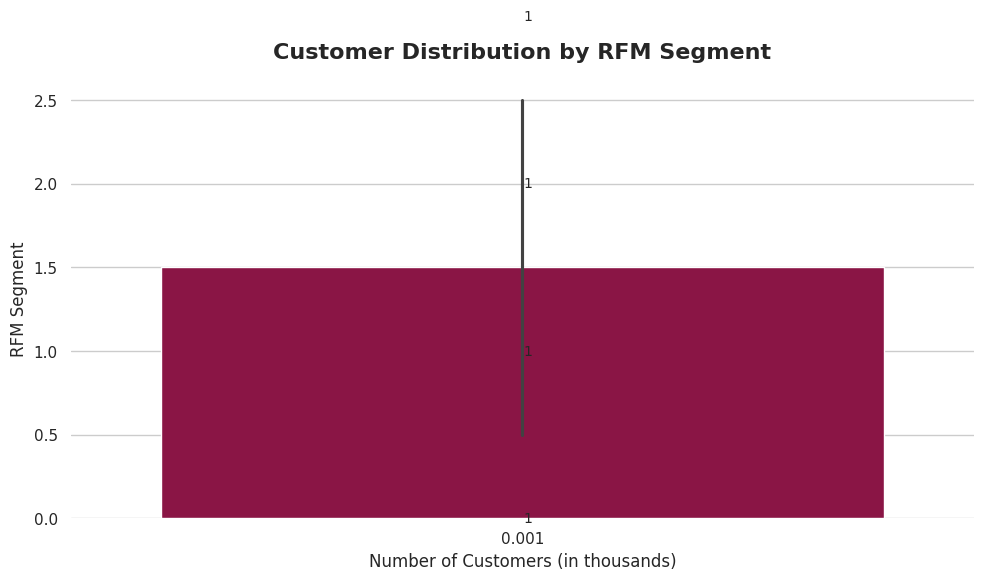

In [20]:
plt.figure(figsize=(10, 6))
sns.set(style="whitegrid")

segment_counts = rfm['CustomerSegment'].value_counts().sort_values()

segment_counts_k = segment_counts.values / 1000
max_scaled_value = segment_counts_k.max()

ax = sns.barplot(x=segment_counts_k, y=segment_counts.index, hue=segment_counts_k, palette='Spectral', legend=False)

for i, value_scaled in enumerate(segment_counts_k):
    original_value = segment_counts.values[i]
    ax.text(value_scaled + max_scaled_value * 0.01, i, str(original_value), va='center', fontsize=10)

plt.title("Customer Distribution by RFM Segment", fontsize=16, weight='bold', pad=15)
plt.xlabel("Number of Customers (in thousands)", fontsize=12)
plt.ylabel("RFM Segment", fontsize=12)
sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.show()